# 1. Global Settings and Initiation

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost
import xgboost as xgb
from xgboost import XGBRegressor

# CatBoost
from catboost import CatBoostRegressor, Pool

# LightGBM
import lightgbm as lgb
from lightgbm import LGBMRegressor, log_evaluation, early_stopping

from sklearn.metrics import mean_squared_log_error

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

print("All libraries loaded successfully.")

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


All libraries loaded successfully.


In [2]:
print("Searching for .pkl files...")
found = False
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.pkl'):
            print(f"FOUND: {os.path.join(dirname, filename)}")
            found = True

if not found:
    print("Still nothing. The dataset is not attached yet.")

Searching for .pkl files...
FOUND: /kaggle/input/final-data-from-preprocessing/y_train.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/X_val.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/test.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/X_train.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/y_val.pkl


In [3]:
base_path = '/kaggle/input/final-data-from-preprocessing/'

# Load the files
X_train = pd.read_pickle(f'{base_path}X_train.pkl')
y_train = pd.read_pickle(f'{base_path}y_train.pkl')
X_val   = pd.read_pickle(f'{base_path}X_val.pkl')
y_val   = pd.read_pickle(f'{base_path}y_val.pkl')
test    = pd.read_pickle(f'{base_path}test.pkl')

print("Data Loaded!")

Data Loaded!


In [4]:
# --- Evaluation metrics helper ---
import numpy as np

def evaluate_forecast(y_true, y_pred, y_train=None, seasonality=7, eps=1e-9):
    import numpy as np
    from sklearn.metrics import mean_squared_log_error

    # --- FIX: force 1D numpy arrays (prevents (n,1)-(n,) broadcasting to (n,n)) ---
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"Shape mismatch: y_true={y_true.shape}, y_pred={y_pred.shape}")

    # Clip to non-negative (sales)
    y_pred_clip = np.clip(y_pred, 0, None)
    y_true_clip = np.clip(y_true, 0, None)

    err = y_pred_clip - y_true_clip
    mae = np.mean(np.abs(err))
    # rmse = np.sqrt(np.mean(err**2)) # redundant with MAE

    # RMSLE (safe)
    rmsle = np.sqrt(mean_squared_log_error(y_true_clip, y_pred_clip))

    # MAPE (ignore zeros in denom)
    # mask = y_true_clip > 0
    # mape = np.mean(np.abs(err[mask] / (y_true_clip[mask] + eps))) if np.any(mask) else np.nan # unstable with zero sales

    # sMAPE (works with zeros)
    smape = np.mean(2.0 * np.abs(err) / (np.abs(y_true_clip) + np.abs(y_pred_clip) + eps))

    # Bias
    bias = np.mean(err)

    # MASE (optional, needs y_train)
    mase = np.nan
    if y_train is not None:
        y_train = np.asarray(y_train).reshape(-1)
        if y_train.shape[0] > seasonality:
            naive_err = np.abs(y_train[seasonality:] - y_train[:-seasonality])
            denom = np.mean(naive_err) + eps
            mase = mae / denom

    return {
        # "RMSE": rmse,
        "MAE": mae,
        "RMSLE": rmsle,
        # "MAPE": mape,
        "sMAPE": smape,
        "Bias": bias,
        "MASE": mase,
    }


def print_metrics(title, metrics_dict):
    print(f"\n{title}")
    for k, v in metrics_dict.items():
        if v is None or (isinstance(v, float) and np.isnan(v)):
            print(f"  {k:7s}: NA")
        elif "MAPE" in k or "sMAPE" in k:
            print(f"  {k:7s}: {v:8.3f}")
        else:
            print(f"  {k:7s}: {v:8.5f}")


In [18]:
# Training metrics
import time, os
import numpy as np

try:
    import psutil
    PROCESS = psutil.Process(os.getpid())
except ImportError:
    psutil = None
    PROCESS = None


def _rss_mb():
    if PROCESS is None:
        return np.nan
    return PROCESS.memory_info().rss / (1024**2)


def profile_trained_model(
    model_name: str,
    predict_fn,
    n_rows: int | None = None,
    save_fn=None,
    run_twice: bool = False
):
    """
    Args:
      model_name: label for reporting
      predict_fn: function that returns predictions (no args)
      n_rows: number of rows predicted on (for throughput). If None, rows/sec = NaN.
      save_fn: optional function (path -> None) to save model; used to compute file size
      run_twice: if True, runs predict twice to check stability (mean abs diff)

    Returns:
      dict with predict time, throughput, RAM delta, optional model size, and preds.
    """
    mem_before = _rss_mb()

    t0 = time.perf_counter()
    preds1 = predict_fn()
    pred_time = time.perf_counter() - t0

    mem_after = _rss_mb()
    ram_delta = mem_after - mem_before if (not np.isnan(mem_after) and not np.isnan(mem_before)) else np.nan

    rows_per_sec = np.nan
    if n_rows is not None and pred_time > 0:
        rows_per_sec = n_rows / pred_time

    model_size_mb = np.nan
    if save_fn is not None:
        tmp_path = f"/mnt/data/{model_name}_model.bin"
        try:
            save_fn(tmp_path)
            model_size_mb = os.path.getsize(tmp_path) / (1024**2)
        except Exception:
            model_size_mb = np.nan

    stability_mean_abs_diff = np.nan
    if run_twice:
        preds2 = predict_fn()
        # Force 1D to avoid broadcasting mistakes
        p1 = np.asarray(preds1).reshape(-1)
        p2 = np.asarray(preds2).reshape(-1)
        if p1.shape == p2.shape:
            stability_mean_abs_diff = float(np.mean(np.abs(p1 - p2)))

    return {
        "model": model_name,
        "predict_time_s": float(pred_time),
        "rows_per_sec": float(rows_per_sec) if not np.isnan(rows_per_sec) else np.nan,
        "ram_before_mb": float(mem_before) if not np.isnan(mem_before) else np.nan,
        "ram_after_mb": float(mem_after) if not np.isnan(mem_after) else np.nan,
        "ram_delta_mb": float(ram_delta) if not np.isnan(ram_delta) else np.nan,
        "model_size_mb": float(model_size_mb) if not np.isnan(model_size_mb) else np.nan,
        "stability_mean_abs_diff": stability_mean_abs_diff,
        "preds": preds1,
    }

In [5]:
# -----------------------------------------------------------------------------
# DEFINE FEATURE GROUPS
# -----------------------------------------------------------------------------

id = 'id'
timestamp = ['date']
target = ['sales']

CATEGORICAL = [
    ### train & test
    'store_nbr',
    'family',
    ### store
    'store_city',
    'store_state',
    'store_type',
    'store_cluster', 
    ### holiday 
    'h_type_nat',
    'h_type_reg',
    'h_type_loc',
]

BOOLEAN = [
    ### time related
    'is_weekend',
    'is_public_payday',
    ### holiday
    'is_national_holiday',
    'is_regional_holiday',
    'is_local_holiday'    
]

NUMERICAL = [
    ### train & test
    'onpromotion',
    ### time related
    'year',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'dow_sin',
    'dow_cos',
    'quarter_sin',
    'quarter_cos',
    ### oil
    'daily_oil_price',
    ### transactions
    # 'transactions',
    # 'log_transactions',
    # 'transactions_rolling_7',
    ### lag r
    # 'sales_lag_7',
]

# Combine all features
FEATURES = CATEGORICAL + BOOLEAN + NUMERICAL

# Define cat_features for CatBoost/LightGBM
cat_features = CATEGORICAL

print(f"Total Features: {len(FEATURES)}")
print(f"Categorical Features: {cat_features}")

Total Features: 25
Categorical Features: ['store_nbr', 'family', 'store_city', 'store_state', 'store_type', 'store_cluster', 'h_type_nat', 'h_type_reg', 'h_type_loc']


In [6]:
# Target Transformation (Log1p)
# This makes the default RMSE objective optimize for RMSLE
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [7]:
!pip install optuna

# 2. Models

## 2.1. CatBoost

In [8]:
train_pool = Pool(
    data=X_train[FEATURES], 
    label=y_train_log, 
    cat_features=cat_features
)

val_pool = Pool(
    data=X_val[FEATURES], 
    label=y_val_log, 
    cat_features=cat_features
)

print("Pools created successfully.")

Pools created successfully.


In [12]:
import optuna
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

def objective_cat(trial):
    params = {
        'task_type': 'GPU',
        'devices': '0',
        'iterations': 800,
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 100,
        'early_stopping_rounds': 50,
        
        # Knobs to Tune:
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
    }
    
    # Initialize Model
    model = CatBoostRegressor(**params)
    
    # Train)
    model.fit(train_pool, eval_set=val_pool)
    
    # Predict & Evaluate
    preds_log = model.predict(val_pool)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds_log))
    
    return rmse

# --- OPTIMIZATION ---
print("Starting CatBoost Hyperparameter Tuning...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=5) 

print("\n------------------------------------------------")
print(f"BEST TRIAL RMSE: {study_cat.best_value:.5f}")
print("BEST PARAMS: ")
for key, value in study_cat.best_params.items():
    print(f"    {key}: {value}")
print("------------------------------------------------")

[I 2026-05-07 12:16:42,053] A new study created in memory with name: no-name-4569a548-f89b-49bb-b2ee-07166c0bd693


Starting CatBoost Hyperparameter Tuning...
0:	learn: 2.4463665	test: 2.3854292	best: 2.3854292 (0)	total: 124ms	remaining: 1m 39s
100:	learn: 0.8192409	test: 0.7519590	best: 0.7519590 (100)	total: 13.3s	remaining: 1m 32s
200:	learn: 0.7027666	test: 0.6952857	best: 0.6952857 (200)	total: 26.4s	remaining: 1m 18s
300:	learn: 0.6450573	test: 0.6691175	best: 0.6691175 (300)	total: 39.6s	remaining: 1m 5s
400:	learn: 0.6069976	test: 0.6528720	best: 0.6528720 (400)	total: 53.3s	remaining: 53.1s
500:	learn: 0.5835974	test: 0.6453810	best: 0.6453810 (500)	total: 1m 6s	remaining: 39.7s
600:	learn: 0.5689302	test: 0.6363913	best: 0.6363913 (600)	total: 1m 19s	remaining: 26.4s
700:	learn: 0.5548327	test: 0.6307792	best: 0.6307171 (690)	total: 1m 33s	remaining: 13.2s
799:	learn: 0.5448680	test: 0.6260816	best: 0.6260816 (799)	total: 1m 46s	remaining: 0us
bestTest = 0.6260815776
bestIteration = 799


[I 2026-05-07 12:18:36,609] Trial 0 finished with value: 0.6260818084997622 and parameters: {'learning_rate': 0.058251572725740504, 'depth': 7, 'l2_leaf_reg': 6, 'min_data_in_leaf': 73}. Best is trial 0 with value: 0.6260818084997622.


0:	learn: 2.5231919	test: 2.4697770	best: 2.4697770 (0)	total: 127ms	remaining: 1m 41s
100:	learn: 1.0252839	test: 0.8958271	best: 0.8958271 (100)	total: 14.7s	remaining: 1m 41s
200:	learn: 0.8544624	test: 0.7621365	best: 0.7621365 (200)	total: 30.2s	remaining: 1m 30s
300:	learn: 0.7738752	test: 0.7271631	best: 0.7271631 (300)	total: 45.6s	remaining: 1m 15s
400:	learn: 0.7258210	test: 0.7059399	best: 0.7059399 (400)	total: 1m	remaining: 1m
500:	learn: 0.6900879	test: 0.6867884	best: 0.6867884 (500)	total: 1m 15s	remaining: 45.3s
600:	learn: 0.6623516	test: 0.6726993	best: 0.6726993 (600)	total: 1m 30s	remaining: 30.1s
700:	learn: 0.6402331	test: 0.6628929	best: 0.6628675 (699)	total: 1m 45s	remaining: 14.9s
799:	learn: 0.6202835	test: 0.6540145	best: 0.6539674 (797)	total: 2m	remaining: 0us
bestTest = 0.6539673837
bestIteration = 797
Shrink model to first 798 iterations.


[I 2026-05-07 12:20:44,382] Trial 1 finished with value: 0.6539674319323767 and parameters: {'learning_rate': 0.02006585809244816, 'depth': 8, 'l2_leaf_reg': 6, 'min_data_in_leaf': 29}. Best is trial 0 with value: 0.6260818084997622.


...

0:	learn: 2.5160795	test: 2.4622337	best: 2.4622337 (0)	total: 157ms	remaining: 2m 5s
100:	learn: 0.9435523	test: 0.8352793	best: 0.8352793 (100)	total: 16.6s	remaining: 1m 54s
200:	learn: 0.7889885	test: 0.7235566	best: 0.7235566 (200)	total: 33.8s	remaining: 1m 40s
300:	learn: 0.7129788	test: 0.6949006	best: 0.6949006 (300)	total: 51.7s	remaining: 1m 25s
400:	learn: 0.6621421	test: 0.6744928	best: 0.6744608 (399)	total: 1m 9s	remaining: 1m 8s
500:	learn: 0.6292011	test: 0.6585465	best: 0.6585465 (500)	total: 1m 25s	remaining: 51.3s
600:	learn: 0.6019106	test: 0.6470245	best: 0.6470057 (597)	total: 1m 43s	remaining: 34.1s
700:	learn: 0.5808081	test: 0.6393765	best: 0.6393765 (700)	total: 2m	remaining: 17s
799:	learn: 0.5643829	test: 0.6317965	best: 0.6317936 (798)	total: 2m 17s	remaining: 0us
bestTest = 0.631793602
bestIteration = 798
Shrink model to first 799 iterations.


[I 2026-05-07 12:25:38,161] Trial 3 finished with value: 0.6317935373240766 and parameters: {'learning_rate': 0.02322891630481811, 'depth': 9, 'l2_leaf_reg': 1, 'min_data_in_leaf': 79}. Best is trial 2 with value: 0.6144614468540727.


0:	learn: 2.5299489	test: 2.4777235	best: 2.4777235 (0)	total: 167ms	remaining: 2m 13s
100:	learn: 1.0381610	test: 0.9423772	best: 0.9423772 (100)	total: 18.5s	remaining: 2m 8s
200:	learn: 0.8159751	test: 0.7595573	best: 0.7595573 (200)	total: 38.4s	remaining: 1m 54s
300:	learn: 0.7370274	test: 0.7137235	best: 0.7137235 (300)	total: 58.4s	remaining: 1m 36s
400:	learn: 0.6874909	test: 0.6895228	best: 0.6895228 (400)	total: 1m 18s	remaining: 1m 17s
500:	learn: 0.6509410	test: 0.6747126	best: 0.6747126 (500)	total: 1m 38s	remaining: 58.7s
600:	learn: 0.6224126	test: 0.6620963	best: 0.6620963 (600)	total: 1m 57s	remaining: 39.1s
700:	learn: 0.5993708	test: 0.6527742	best: 0.6527742 (700)	total: 2m 16s	remaining: 19.3s
799:	learn: 0.5820566	test: 0.6466769	best: 0.6466769 (799)	total: 2m 36s	remaining: 0us
bestTest = 0.6466768815
bestIteration = 799


[I 2026-05-07 12:28:23,088] Trial 4 finished with value: 0.6466769983461846 and parameters: {'learning_rate': 0.016389252334977004, 'depth': 10, 'l2_leaf_reg': 3, 'min_data_in_leaf': 50}. Best is trial 2 with value: 0.6144614468540727.



------------------------------------------------
BEST TRIAL RMSE: 0.61446
BEST PARAMS: 
    learning_rate: 0.04246500397788938
    depth: 9
    l2_leaf_reg: 7
    min_data_in_leaf: 9
------------------------------------------------


In [13]:
cat_model = CatBoostRegressor(
    task_type= 'GPU',
    devices= '0:1',
    iterations= 3000,
    learning_rate= 0.04246500397788938,
    depth= 9,
    l2_leaf_reg= 7,
    min_data_in_leaf= 9,
    loss_function= 'RMSE',
    random_seed= 42,
    verbose= 100,
    early_stopping_rounds= 50
)

cat_model.fit(train_pool, eval_set=val_pool)

0:	learn: 2.4761332	test: 2.4195714	best: 2.4195714 (0)	total: 160ms	remaining: 7m 59s
100:	learn: 0.7991218	test: 0.7347165	best: 0.7347165 (100)	total: 17s	remaining: 8m 9s
200:	learn: 0.6756926	test: 0.6834791	best: 0.6834668 (199)	total: 34.5s	remaining: 8m
300:	learn: 0.6129669	test: 0.6559150	best: 0.6559150 (300)	total: 51.6s	remaining: 7m 42s
400:	learn: 0.5754008	test: 0.6414488	best: 0.6414488 (400)	total: 1m 9s	remaining: 7m 27s
500:	learn: 0.5519452	test: 0.6327051	best: 0.6327051 (500)	total: 1m 26s	remaining: 7m 9s
600:	learn: 0.5348203	test: 0.6252396	best: 0.6252396 (600)	total: 1m 43s	remaining: 6m 53s
700:	learn: 0.5214361	test: 0.6193909	best: 0.6193755 (699)	total: 2m	remaining: 6m 35s
800:	learn: 0.5106436	test: 0.6144705	best: 0.6144705 (800)	total: 2m 18s	remaining: 6m 19s
900:	learn: 0.5023698	test: 0.6109023	best: 0.6108879 (898)	total: 2m 35s	remaining: 6m 1s
1000:	learn: 0.4947796	test: 0.6082349	best: 0.6082349 (1000)	total: 2m 52s	remaining: 5m 44s
1100:	le

In [14]:
# 1. Get the Raw Log Predictions from the model
cat_pred_log = cat_model.predict(val_pool)

cat_pred_real = np.expm1(cat_pred_log)
cat_pred_real = np.maximum(cat_pred_real, 0)

# 3. Calculate the True RMSLE
# We use y_val (Real Targets) vs y_pred_real (Real Predictions)
# sklearn's mean_squared_log_error handles the log math internally
try:
    cat_rmsle = np.sqrt(mean_squared_log_error(y_val, cat_pred_real))
    print(f"Validation RMSLE: {cat_rmsle:.5f}")
except Exception as e:
    print("Error calculating RMSLE. Ensure y_val is in 'Real Sales' units (not logged).")
    print(e)

# Evaluation metrics
CatBoost_metrics = evaluate_forecast(y_val, cat_pred_real, y_train=y_train, seasonality=7)
print_metrics("CatBoost validation metrics", CatBoost_metrics)

Validation RMSLE: 0.59645

CatBoost validation metrics
  MAE    : 111.96670
  RMSLE  :  0.59645
  sMAPE  :    0.569
  Bias   : -76.65512
  MASE   :  1.19631


In [19]:
cat_profile = profile_trained_model(
    "catboost",
    predict_fn=lambda: cat_model.predict(val_pool),
    n_rows=val_pool.num_row(),
    save_fn=lambda path: cat_model.save_model(path),
    run_twice=True
)

cat_pred_log = cat_profile["preds"]
print({k:v for k,v in cat_profile.items() if k!="preds"})


{'model': 'catboost', 'predict_time_s': 4.8713894709999295, 'rows_per_sec': 100339.54437637431, 'ram_before_mb': 1471.96484375, 'ram_after_mb': 1466.33984375, 'ram_delta_mb': -5.625, 'model_size_mb': nan, 'stability_mean_abs_diff': 0.0}


**Feature Importance for CatBoost**

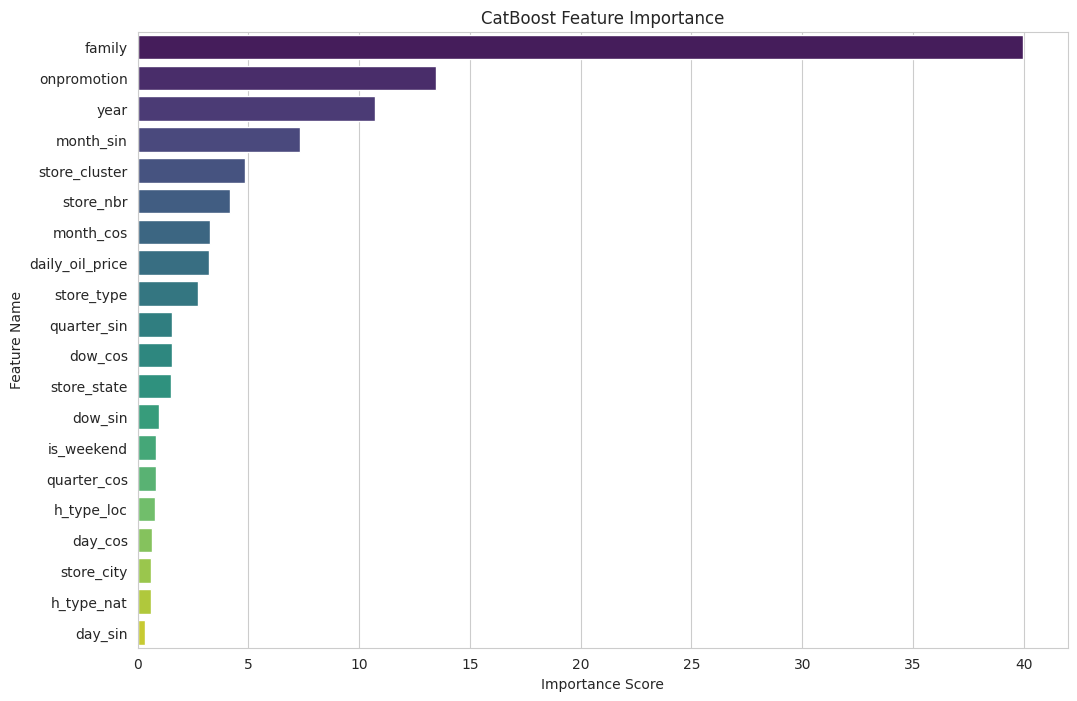

Zero Importance Features: []


In [20]:
# 1. Get the scores
feature_importance = cat_model.get_feature_importance()

# 2. Get the feature names
feature_names = cat_model.feature_names_ 

# 3. Create a sorted DataFrame
fi_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
fi_df = fi_df.sort_values(by='importance', ascending=False)

# 4. Plot the Top 20
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=fi_df.head(20), palette='viridis')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

print("Zero Importance Features:", fi_df[fi_df['importance'] == 0]['feature'].tolist())

Version 2 Summary:

Model: CatBoost (GPU)

Validation RMSLE: around 0.65232

Notes: Feature importance shows family and promotion are key.

## 2.2. **XGBoost**

In [21]:
# -----------------------------------------------------------------------------
# XGBOOST PREPARATION
# Fix for "TypeError: int has no len()"
# -----------------------------------------------------------------------------

def make_categories_strings(df, cat_cols):
    """
    XGBoost with enable_categorical=True prefers categories to be string-based
    or strictly 'category' dtype to avoid ambiguity with integers.
    """
    df_mod = df.copy()
    # Ensure we only touch the columns we defined as categorical
    for col in cat_cols:
        if col in df_mod.columns:
            df_mod[col] = df_mod[col].astype(str).astype('category')
    return df_mod

# Apply the fix using the 'CATEGORICAL' list you defined earlier
X_train_fixed = make_categories_strings(X_train[FEATURES], CATEGORICAL)
X_val_fixed   = make_categories_strings(X_val[FEATURES], CATEGORICAL)

print("XGBoost data prepared successfully.")

XGBoost data prepared successfully.


In [23]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective_xgb(trial):
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'enable_categorical': True,
        'n_estimators': 8000,
        'early_stopping_rounds': 50,
        'verbosity': 0,
        'random_state': 42,
        'n_jobs': -1,
        
        # Tuning Knobs:
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train_fixed, y_train_log,
        eval_set=[(X_val_fixed, y_val_log)],
        verbose=False
    )
    
    preds_log = model.predict(X_val_fixed)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds_log))
    
    return rmse

# --- OPTIMIZATION ---
print("Starting XGBoost Hyperparameter Tuning (5 Runs)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=5)

print("\n------------------------------------------------")
print(f"BEST XGB TRIAL RMSE: {study_xgb.best_value:.5f}")
print("BEST XGB PARAMS: ")
for key, value in study_xgb.best_params.items():
    print(f"    {key}: {value}")
print("------------------------------------------------")

[I 2026-05-07 12:44:32,107] A new study created in memory with name: no-name-888c7357-5f2b-46f2-b032-d8f8f8969380


Starting XGBoost Hyperparameter Tuning (5 Runs)...


[I 2026-05-07 12:44:41,504] Trial 0 finished with value: 0.627115888056824 and parameters: {'learning_rate': 0.09222040461897915, 'max_depth': 8, 'subsample': 0.9432540959083331, 'colsample_bytree': 0.9907637889507309, 'min_child_weight': 5, 'reg_alpha': 4.89169121276058, 'reg_lambda': 1.8073486939784593}. Best is trial 0 with value: 0.627115888056824.
[I 2026-05-07 12:46:06,469] Trial 1 finished with value: 0.6060468559484454 and parameters: {'learning_rate': 0.014265439166576669, 'max_depth': 6, 'subsample': 0.8613186756413198, 'colsample_bytree': 0.9374201432852995, 'min_child_weight': 2, 'reg_alpha': 3.1814492330835398, 'reg_lambda': 4.121697097505345}. Best is trial 1 with value: 0.6060468559484454.
[I 2026-05-07 12:46:41,193] Trial 2 finished with value: 0.6225299185338461 and parameters: {'learning_rate': 0.045211734612501185, 'max_depth': 11, 'subsample': 0.6547386738430084, 'colsample_bytree': 0.6847487394392047, 'min_child_weight': 4, 'reg_alpha': 0.5603365170845304, 'reg_lam


------------------------------------------------
BEST XGB TRIAL RMSE: 0.60517
BEST XGB PARAMS: 
    learning_rate: 0.024918770263802882
    max_depth: 8
    subsample: 0.7672476358768971
    colsample_bytree: 0.6352299038829797
    min_child_weight: 4
    reg_alpha: 0.8187302278670266
    reg_lambda: 4.488893134386025
------------------------------------------------


In [24]:
xgb_model = XGBRegressor(
    tree_method="hist",
    device="cuda",
    enable_categorical=True, 
    n_estimators=3000,
    learning_rate=0.024918770263802882,
    max_depth=8,
    subsample=0.7672476358768971,
    colsample_bytree=0.6352299038829797,
    random_state=42,
    min_child_weight= 4,
    n_jobs=-1,
    early_stopping_rounds=50,
    reg_alpha= 0.8187302278670266,
    reg_lambda= 4.488893134386025
)

xgb_model.fit(
    X_train_fixed, y_train_log,
    eval_set=[(X_train_fixed, y_train_log), (X_val_fixed, y_val_log)],
    verbose=100
)

[0]	validation_0-rmse:2.50898	validation_1-rmse:2.45807
[100]	validation_0-rmse:0.91172	validation_1-rmse:0.78491
[200]	validation_0-rmse:0.63173	validation_1-rmse:0.65394
[300]	validation_0-rmse:0.55049	validation_1-rmse:0.63354
[400]	validation_0-rmse:0.51678	validation_1-rmse:0.62380
[500]	validation_0-rmse:0.49072	validation_1-rmse:0.61654
[600]	validation_0-rmse:0.47607	validation_1-rmse:0.61288
[700]	validation_0-rmse:0.46442	validation_1-rmse:0.61063
[800]	validation_0-rmse:0.45695	validation_1-rmse:0.60798
[900]	validation_0-rmse:0.45109	validation_1-rmse:0.60729
[1000]	validation_0-rmse:0.44620	validation_1-rmse:0.60648
[1100]	validation_0-rmse:0.44183	validation_1-rmse:0.60586
[1200]	validation_0-rmse:0.43801	validation_1-rmse:0.60553
[1300]	validation_0-rmse:0.43447	validation_1-rmse:0.60526
[1371]	validation_0-rmse:0.43197	validation_1-rmse:0.60524


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6352299038829797, device='cuda',
             early_stopping_rounds=50, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.024918770263802882,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=4, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=3000, n_jobs=-1,
             num_parallel_tree=None, ...)

In [25]:
xgb_pred_log = xgb_model.predict(X_val_fixed)

xgb_pred_real = np.expm1(xgb_pred_log)
xgb_pred_real = np.maximum(xgb_pred_real, 0)

try:
    xgb_rmsle = np.sqrt(mean_squared_log_error(y_val, xgb_pred_real))
    print(f"XGBoost Validation RMSLE: {xgb_rmsle:.5f}")
except Exception as e:
    print("Error:", e)

# Evaluation metrics
XGBoost_metrics = evaluate_forecast(y_val, xgb_pred_real, y_train=y_train, seasonality=7)
print_metrics("XGBoost validation metrics", XGBoost_metrics)

XGBoost Validation RMSLE: 0.60465

XGBoost validation metrics
  MAE    : 103.84063
  RMSLE  :  0.60465
  sMAPE  :    0.574
  Bias   : -67.97972
  MASE   :  1.10948


In [26]:
xgb_profile = profile_trained_model(
    "xgboost",
    predict_fn=lambda: xgb_model.predict(X_val_fixed),
    n_rows=X_val_fixed.shape[0],
    save_fn=lambda path: xgb_model.save_model(path),
    run_twice=True
)

xgb_pred_log = xgb_profile["preds"]
print({k:v for k,v in xgb_profile.items() if k!="preds"})

{'model': 'xgboost', 'predict_time_s': 0.5413950460001615, 'rows_per_sec': 902839.8091397648, 'ram_before_mb': 2229.5078125, 'ram_after_mb': 2229.5078125, 'ram_delta_mb': 0.0, 'model_size_mb': nan, 'stability_mean_abs_diff': 0.0}


**Feature Importance for XGBoost**

<Figure size 1000x800 with 0 Axes>

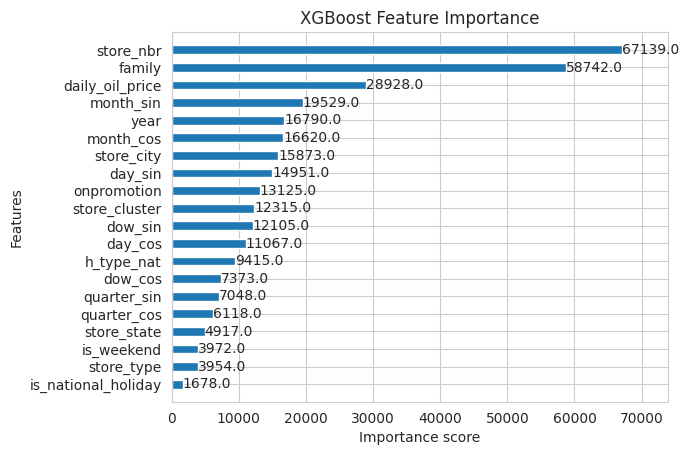

In [27]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=20, height=0.5, title="XGBoost Feature Importance")
plt.show()

## 2.3. LightGBM

In [29]:
import optuna
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_squared_error

def objective_lgb(trial):
    params = {
        'objective': 'rmse',
        'n_estimators': 800,
        'random_state': 42,
        'n_jobs': -1,
        'device': 'gpu',
        'verbosity': -1,
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 6, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
    }
    
    model = LGBMRegressor(**params)
    
    model.fit(
        X_train[FEATURES], 
        y_train_log,
        eval_set=[(X_val[FEATURES], y_val_log)],
        eval_metric='rmse',
        categorical_feature=cat_features,
        callbacks=[
            early_stopping(stopping_rounds=50, verbose=False)
        ]
    )
    
    preds_log = model.predict(X_val[FEATURES])
    rmse = np.sqrt(mean_squared_error(y_val_log, preds_log))
    
    return rmse

# --- OPTIMIZATION  ---
print("Starting LightGBM Hyperparameter Tuning (5 Runs)...")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=5)

print("\n------------------------------------------------")
print(f"BEST LGB TRIAL RMSE: {study_lgb.best_value:.5f}")
print("BEST LGB PARAMS: ")
for key, value in study_lgb.best_params.items():
    print(f"    {key}: {value}")
print("------------------------------------------------")

[I 2026-05-07 12:49:26,242] A new study created in memory with name: no-name-ab29f788-af9d-4fb7-92f5-f37c1d647616


Starting LightGBM Hyperparameter Tuning (5 Runs)...


[I 2026-05-07 12:50:24,218] Trial 0 finished with value: 0.615152908011749 and parameters: {'learning_rate': 0.051352944098028784, 'num_leaves': 44, 'max_depth': 15, 'min_child_samples': 97, 'subsample': 0.989518663128448, 'colsample_bytree': 0.6832414790276325, 'reg_alpha': 1.9518580375530148, 'reg_lambda': 0.6040176624282789}. Best is trial 0 with value: 0.615152908011749.
[I 2026-05-07 12:51:39,150] Trial 1 finished with value: 0.6069136546304487 and parameters: {'learning_rate': 0.0394372743495598, 'num_leaves': 93, 'max_depth': 14, 'min_child_samples': 74, 'subsample': 0.7067937383657412, 'colsample_bytree': 0.7623306928398527, 'reg_alpha': 6.881237288993843, 'reg_lambda': 7.083311265921871}. Best is trial 1 with value: 0.6069136546304487.
[I 2026-05-07 12:52:39,777] Trial 2 finished with value: 0.6084061090206071 and parameters: {'learning_rate': 0.059025698670744045, 'num_leaves': 67, 'max_depth': 13, 'min_child_samples': 63, 'subsample': 0.9965411284502618, 'colsample_bytree': 


------------------------------------------------
BEST LGB TRIAL RMSE: 0.60691
BEST LGB PARAMS: 
    learning_rate: 0.0394372743495598
    num_leaves: 93
    max_depth: 14
    min_child_samples: 74
    subsample: 0.7067937383657412
    colsample_bytree: 0.7623306928398527
    reg_alpha: 6.881237288993843
    reg_lambda: 7.083311265921871
------------------------------------------------


In [31]:
warnings.filterwarnings('ignore')

lgb_model = LGBMRegressor(
    objective='rmse',
    n_estimators=3000,
    
    learning_rate=0.0394372743495598,
    num_leaves=93,
    random_state=42,
    n_jobs=-1,
    device='gpu',
    verbosity=-1,
    max_depths= 14,
    min_child_samples= 74,
    subsample= 0.7067937383657412,
    colsample_bytree= 0.7623306928398527,
    reg_alpha= 6.881237288993843,
    reg_lambda= 7.083311265921871
)

lgb_model.fit(
    X_train[FEATURES],
    y_train_log,
    eval_set=[(X_val[FEATURES], y_val_log)],
    eval_metric='rmse',
    categorical_feature=cat_features,
    callbacks=[
        log_evaluation(100),
        early_stopping(50, verbose=False)
    ]
)

[100]	valid_0's rmse: 0.666093
[200]	valid_0's rmse: 0.635086
[300]	valid_0's rmse: 0.622204
[400]	valid_0's rmse: 0.616241
[500]	valid_0's rmse: 0.613374
[600]	valid_0's rmse: 0.61135
[700]	valid_0's rmse: 0.610089
[800]	valid_0's rmse: 0.60923
[900]	valid_0's rmse: 0.607937
[1000]	valid_0's rmse: 0.607476
[1100]	valid_0's rmse: 0.607201


LGBMRegressor(colsample_bytree=0.7623306928398527, device='gpu',
              learning_rate=0.0394372743495598, max_depths=14,
              min_child_samples=74, n_estimators=3000, n_jobs=-1, num_leaves=93,
              objective='rmse', random_state=42, reg_alpha=6.881237288993843,
              reg_lambda=7.083311265921871, subsample=0.7067937383657412,
              verbosity=-1)

In [32]:
lgb_pred_log = lgb_model.predict(X_val[FEATURES])

lgb_pred_real = np.expm1(lgb_pred_log)
lgb_pred_real = np.maximum(lgb_pred_real, 0)

try:
    lgb_rmsle = np.sqrt(mean_squared_log_error(y_val, lgb_pred_real))
    print(f"LightGBM Validation RMSLE: {lgb_rmsle:.5f}")
except Exception as e:
    print(f"Error calculating RMSLE: {e}")

# Evaluation metrics
LightGBM_metrics = evaluate_forecast(y_val, lgb_pred_real, y_train=y_train, seasonality=7)
print_metrics("LightGBM validation metrics", LightGBM_metrics)

LightGBM Validation RMSLE: 0.60660

LightGBM validation metrics
  MAE    : 98.93626
  RMSLE  :  0.60660
  sMAPE  :    0.566
  Bias   : -62.80120
  MASE   :  1.05708


In [33]:
lgb_profile = profile_trained_model(
    "lightgbm",
    predict_fn=lambda: lgb_model.predict(X_val[FEATURES]),
    n_rows=X_val[FEATURES].shape[0],
    save_fn=lambda path: lgb_model.booster_.save_model(path),
    run_twice=True
)

lgb_pred_log = lgb_profile["preds"]
print({k:v for k,v in lgb_profile.items() if k!="preds"})


[LightGBM] [Fatal] Model file /mnt/data/lightgbm_model.bin is not available for writes


{'model': 'lightgbm', 'predict_time_s': 28.268999253999937, 'rows_per_sec': 17290.778340193207, 'ram_before_mb': 2895.0703125, 'ram_after_mb': 2895.07421875, 'ram_delta_mb': 0.00390625, 'model_size_mb': nan, 'stability_mean_abs_diff': 0.0}


**Feature Importance for LightGBM**

<Figure size 1000x800 with 0 Axes>

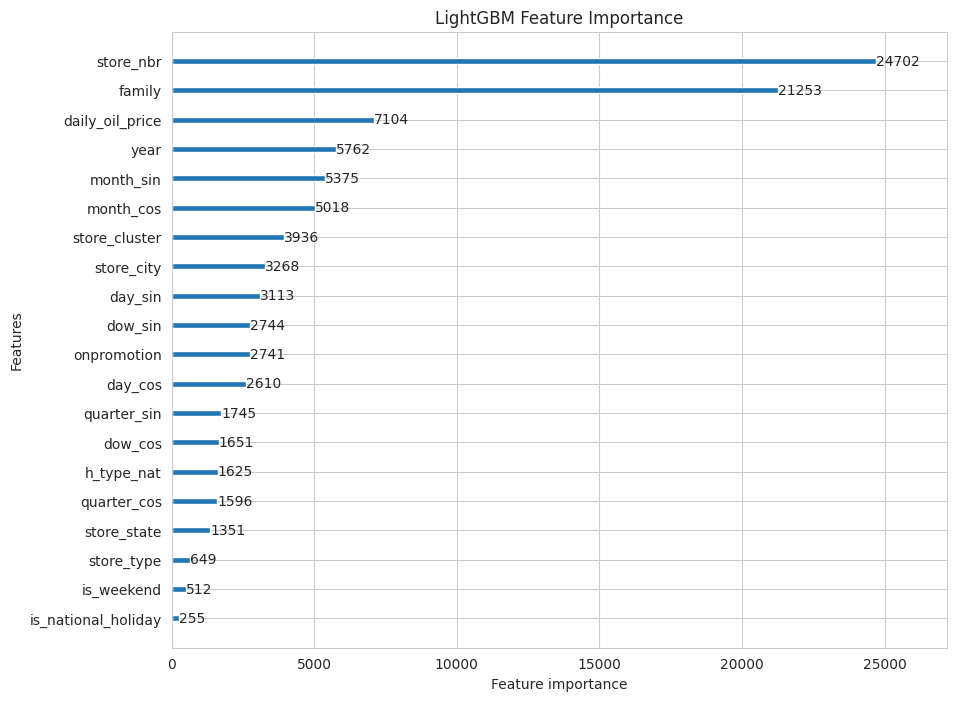

In [34]:
plt.figure(figsize=(10, 8))
lgb.plot_importance(lgb_model, max_num_features=20, figsize=(10, 8), title="LightGBM Feature Importance")
plt.show()

## 2.4. Ensemble

In [35]:
# Average of All three
final_predictions = (xgb_pred_real + cat_pred_real + lgb_pred_real) / 3

# Calculate the Ensemble Score
ensemble_rmsle = np.sqrt(mean_squared_log_error(y_val, final_predictions))

print(f"Ensemble Validation Score: {ensemble_rmsle:.5f}")

# Evaluation metrics
Ensemble_metrics = evaluate_forecast(y_val, final_predictions, y_train=y_train, seasonality=7)
print_metrics("Ensemble validation metrics", Ensemble_metrics)

Ensemble Validation Score: 0.59285

Ensemble validation metrics
  MAE    : 100.56987
  RMSLE  :  0.59285
  sMAPE  :    0.571
  Bias   : -69.14535
  MASE   :  1.07454


In [37]:
profiles = [
    cat_profile,
    xgb_profile,
    lgb_profile,
]

summary = [
    {
        "model": p["model"],
        "predict_time_s": p["predict_time_s"],
        "rows_per_sec": p["rows_per_sec"],
        "ram_delta_mb": p["ram_delta_mb"],
        "model_size_mb": p["model_size_mb"],
        "stability_mean_abs_diff": p["stability_mean_abs_diff"],
    }
    for p in profiles
]

summary


[{'model': 'catboost',
  'predict_time_s': 4.8713894709999295,
  'rows_per_sec': 100339.54437637431,
  'ram_delta_mb': -5.625,
  'model_size_mb': nan,
  'stability_mean_abs_diff': 0.0},
 {'model': 'xgboost',
  'predict_time_s': 0.5413950460001615,
  'rows_per_sec': 902839.8091397648,
  'ram_delta_mb': 0.0,
  'model_size_mb': nan,
  'stability_mean_abs_diff': 0.0},
 {'model': 'lightgbm',
  'predict_time_s': 28.268999253999937,
  'rows_per_sec': 17290.778340193207,
  'ram_delta_mb': 0.00390625,
  'model_size_mb': nan,
  'stability_mean_abs_diff': 0.0}]

# 3. Submission

In [38]:
# -----------------------------------------------------------------------------
# GENERATE TEST PREDICTIONS
# -----------------------------------------------------------------------------

print("Preparing Test Data...")

# 1. Prepare Test Feature Sets
# Standard for CatBoost/LGBM
X_test_cat = test[FEATURES].copy()

# Fixed strings for XGBoost (using the helper function defined earlier)
X_test_fixed = make_categories_strings(X_test_cat, CATEGORICAL)

print("Predicting with CatBoost...")
pred_log_cat = cat_model.predict(X_test_cat)

print("Predicting with XGBoost...")
pred_log_xgb = xgb_model.predict(X_test_fixed)

print("Predicting with LightGBM...")
pred_log_lgb = lgb_model.predict(X_test_cat)

# 2. Reverse Log Transformation & Clip Negatives
pred_real_cat = np.maximum(np.expm1(pred_log_cat), 0)
pred_real_xgb = np.maximum(np.expm1(pred_log_xgb), 0)
pred_real_lgb = np.maximum(np.expm1(pred_log_lgb), 0)

# 3. Ensemble Average
final_test_pred = (pred_real_cat + pred_real_xgb + pred_real_lgb) / 3

# 4. Create Submission File
submission = pd.DataFrame({
    'id': test['id'],
    'sales': final_test_pred
})

# Save
submission.to_csv('submission.csv', index=False)
print("Success! Submission saved to 'submission.csv'")

# Quick Sanity Check
print(submission.head())

Preparing Test Data...
Predicting with CatBoost...
Predicting with XGBoost...
Predicting with LightGBM...
Success! Submission saved to 'submission.csv'
        id     sales
0  3000888  3.641272
1  3002670  3.208307
2  3004452  3.473829
3  3006234  3.308763
4  3008016  1.441017


In [39]:
print(pd.read_csv('submission.csv').head())

        id     sales
0  3000888  3.641272
1  3002670  3.208307
2  3004452  3.473829
3  3006234  3.308763
4  3008016  1.441017
